In [2]:
using Pkg
Pkg.activate("/home/camilla/u1symmetry")
Pkg.status()

  Activating project at `~/u1symmetry`


Status `~/u1symmetry/Project.toml`
  [6e4b80f9] BenchmarkTools v1.8.0
  [13f3f980] CairoMakie v0.15.10
  [7a1cc6ca] FFTW v1.10.0
  [7073ff75] IJulia v1.34.4
  [1dea7af3] OrdinaryDiffEq v7.0.0
  [6c2fb7c5] QuantumToolbox v0.47.0
  [295af30f] Revise v3.14.3
  [90137ffa] StaticArrays v1.9.18
  [789caeaf] StochasticDiffEq v7.0.0
  [2f01184e] SparseArrays v1.12.0


In [3]:
using QuantumToolbox
using LinearAlgebra
include("enlargedspace.jl")
using .SuperEnrSpace


In [4]:
using CairoMakie

# One site case
$$\hat{H} = \omega_0 \hat{a}^\dagger\hat{a} + \frac{U}{2}\hat{a}^{\dagger 2}\hat{a}^2$$
with $\mathcal{D}[\hat{a}]$ and $\mathcal{D}[\hat{a^2}]$\\
Vectorized representation of Lindblad equation: 
$$\mathcal{L}\ket{\rho} = -i(H-\tilde{H})\ket{\rho} + \sum_i \gamma_i (\sigma_{L_i}L_i\tilde{L}_i - \frac{1}{2}L_i^\dagger L_i - \frac{1}{2}\tilde{L}_i^\dagger \tilde{L}_i)\ket{\rho}$$

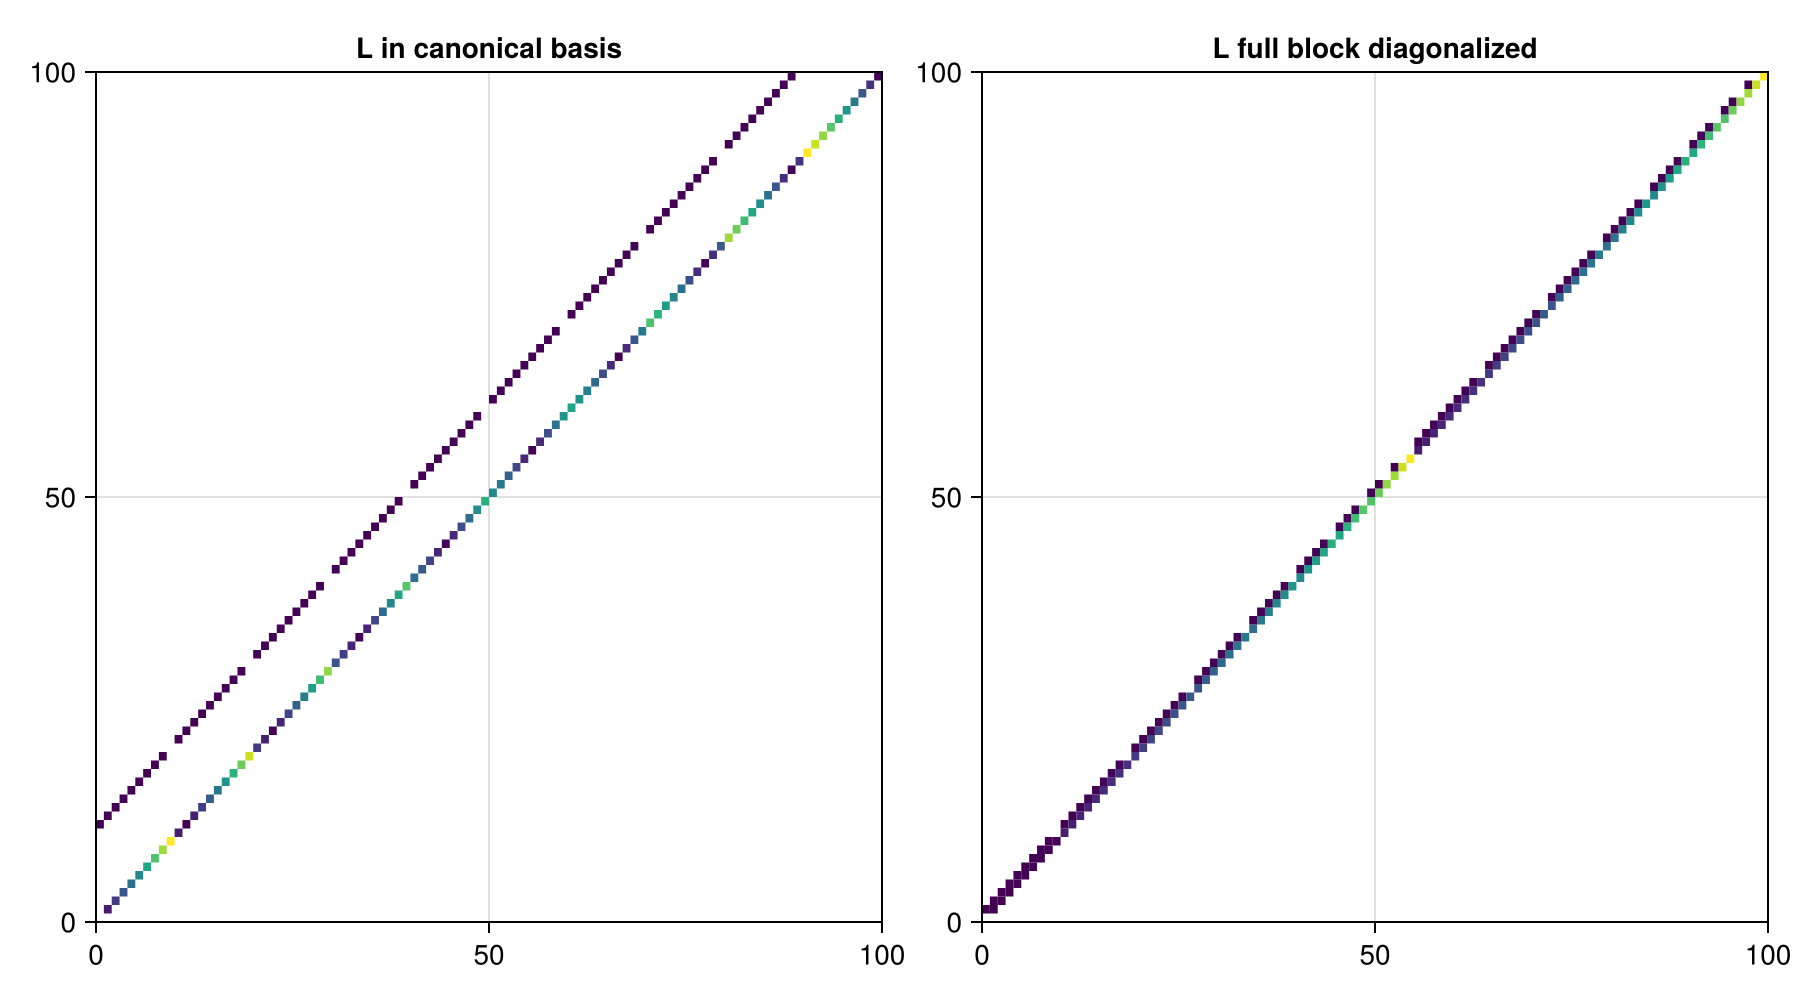

CairoMakie.Screen{IMAGE}


In [8]:
cutoff = 10
a = destroy(cutoff)
ω = 10.
U = 1.
γ = 0.1
H = ω * a' * a + U/2 * a'^2 * a^2
L = liouvillian(H, [sqrt(γ)*a]);
L_diag = block_diagonal_form(L)

fig = Figure(size = (900,500))
ax1 = Axis(fig[1,1], title = "L in canonical basis")
ax2 = Axis(fig[1,2], title="L full block diagonalized")
spy!(ax1, abs.(L.data))
spy!(ax2, abs.(L_diag.B.data))
display(fig)





0.0
ComplexF64[]


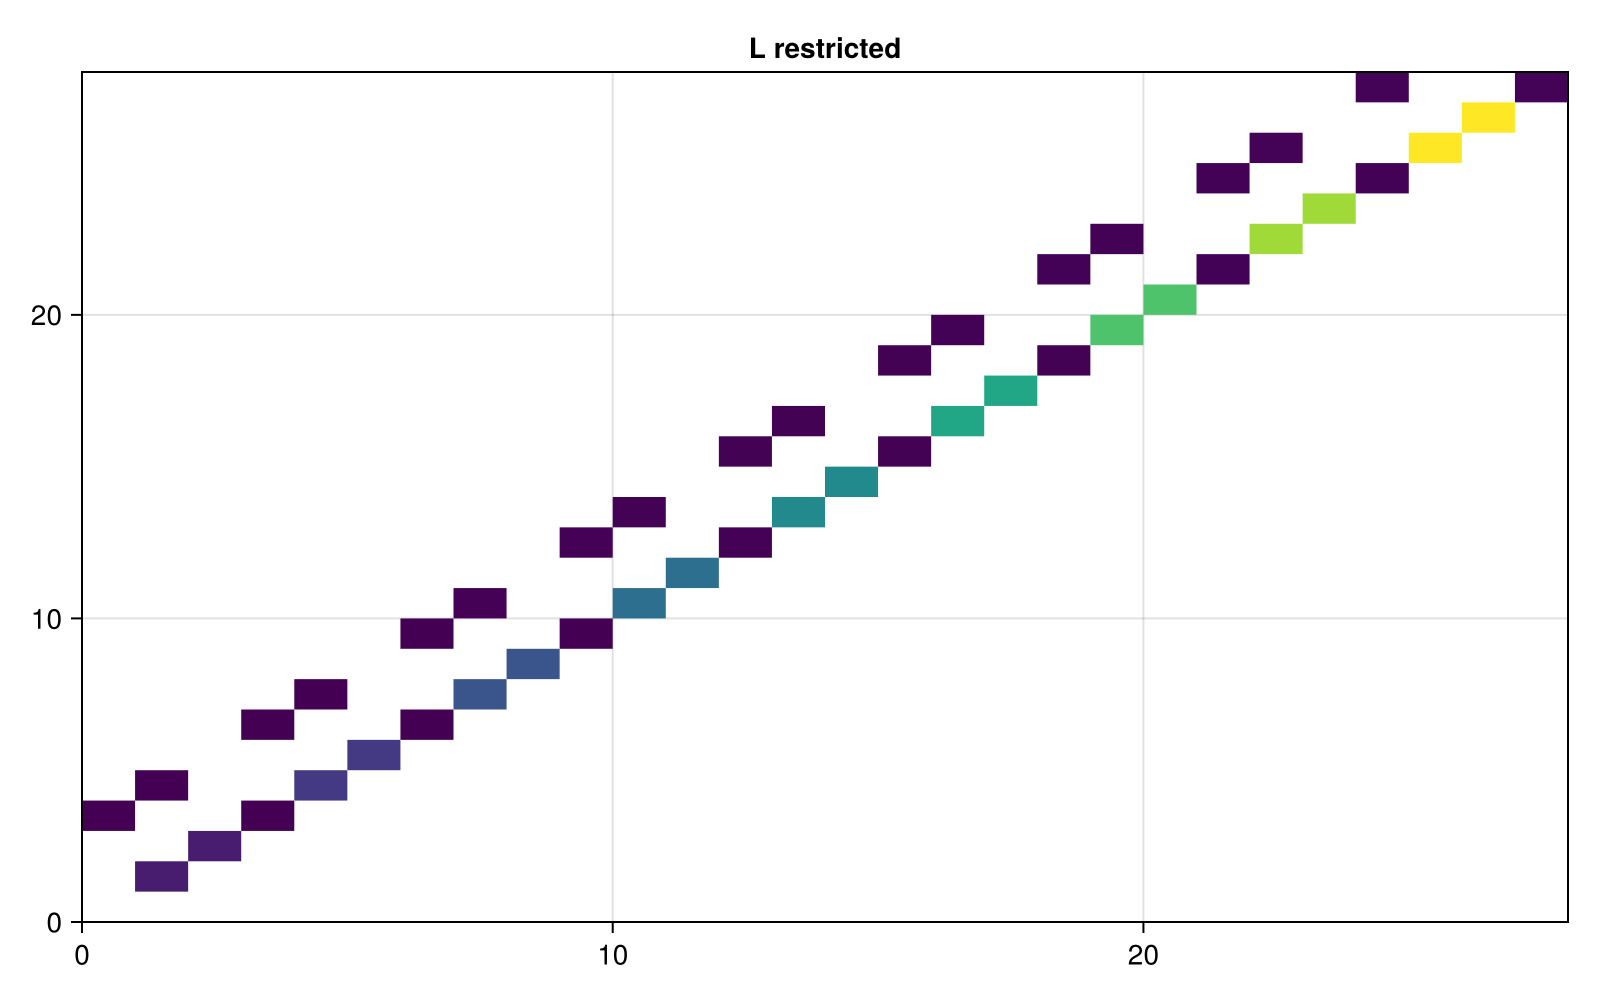

CairoMakie.Screen{IMAGE}


In [12]:
"""
case of restricted space
"""
space = s_enrspace((10,),1,0)
vec_id = s_identity(space)
a_left, a_right = s_destroy(space, 1)
H_left = ω * a_left' * a_left + (U/2) * a_left'^2 * a_left^2
H_right = ω * a_right' * a_right + (U/2) * a_right'^2 * a_right^2

# Lindblad part: dissipator D[a] = a ρ a† - ½{a†a, ρ}
# vectorized: a_left * a_right† - ½(a†a)_left - ½(a†a)_right
diss = a_left * a_right - 0.5 * a_left' * a_left - 0.5 * a_right' * a_right

# total Liouvillian
L_restricted = -1im * (H_left - H_right) + γ * diss
result = (vec_id' * L_restricted).data
# Finds values whose magnitude is greater than a tiny threshold
nonzero_values = filter(x -> abs(x) > 1e-9, result)
println(maximum(abs, result))
println(nonzero_values)
fig = Figure(size = (800,500))
ax = Axis(fig[1,1], title = "L restricted")
spy!(ax, abs.(L_restricted.data))
display(fig)

In [21]:
evals_full = eigvals(Matrix(L.data))
evals_restricted = eigvals(Matrix(L_restricted.data))

evals_restricted .∈ Ref(evals_full)

# the restricted eigenvalues should be a subset of the full ones
# specifically, the ones corresponding to the |q| ≤ n_exc blocks

28-element BitVector:
 0
 0
 0
 0
 1
 0
 0
 0
 0
 1
 ⋮
 1
 0
 0
 0
 0
 1
 1
 1
 1